Setup

In [138]:
import heapq
import random
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
import matplotlib.animation as animation

In [139]:
# Using these same values everywhere, to keep consistency between plots and animations
EMPTY = 0
WALL = -1
ITEM = 2
ITEM_PICKED = 1.2
START = 2.2
AGENT = 3

CMAP = "GnBu"

Grid layout

In [140]:
# Grid Size
grid_width = 42
grid_height = 42

grid = [[0 for _ in range(grid_width)] for _ in range(grid_height)]

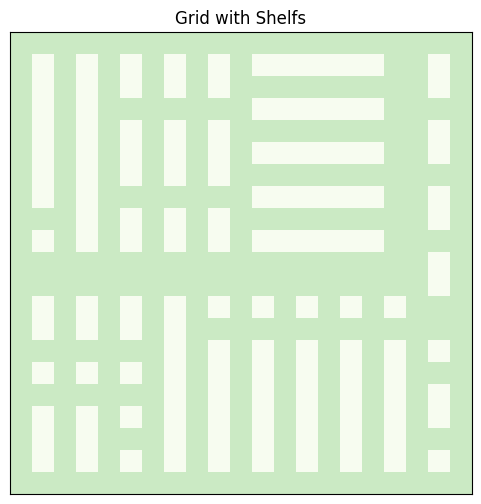

In [141]:
# Function to add a shelf to the grid
def add_shelf(grid, top_left, bottom_right):
    x1, y1 = top_left
    x2, y2 = bottom_right
    
    for y in range(y1, y2):
        for x in range(x1, x2):
            grid[y][x] = 1


# Function where we create our layout with all our shelfs            
def create_store_layout(grid):
    add_shelf(grid, (2, 2), (4, 16))
    add_shelf(grid, (2, 18), (4, 20))
    add_shelf(grid, (6, 2), (8, 20))
    add_shelf(grid, (10, 2), (12, 6))
    add_shelf(grid, (10, 8), (12, 14))
    add_shelf(grid, (10, 16), (12, 20))
    add_shelf(grid, (14, 2), (16, 6))
    add_shelf(grid, (14, 8), (16, 14))
    add_shelf(grid, (14, 16), (16, 20))
    add_shelf(grid, (18, 2), (20, 6))
    add_shelf(grid, (18, 8), (20, 14))
    add_shelf(grid, (18, 16), (20, 20))
    add_shelf(grid, (22, 2), (34, 4))
    add_shelf(grid, (22, 6), (34, 8))
    add_shelf(grid, (22, 10), (34, 12))
    add_shelf(grid, (22, 14), (34, 16))
    add_shelf(grid, (22, 18), (34, 20))
    add_shelf(grid, (38, 2), (40, 6))
    add_shelf(grid, (38, 8), (40, 12))
    add_shelf(grid, (38, 14), (40, 18))
    add_shelf(grid, (38, 20), (40, 24)) 
    add_shelf(grid, (38, 28), (40, 30))
    add_shelf(grid, (38, 32), (40, 36))
    add_shelf(grid, (38, 38), (40, 40))
    add_shelf(grid, (2, 24), (4, 28))
    add_shelf(grid, (2, 30), (4, 32)) 
    add_shelf(grid, (2, 34), (4, 40))
    add_shelf(grid, (6, 24), (8, 28))
    add_shelf(grid, (6, 30), (8, 32)) 
    add_shelf(grid, (6, 34), (8, 40))
    add_shelf(grid, (10, 24), (12, 28))
    add_shelf(grid, (10, 30), (12, 32)) 
    add_shelf(grid, (10, 34), (12, 36))
    add_shelf(grid, (10, 38), (12, 40))
    add_shelf(grid, (14, 24), (16, 40))
    add_shelf(grid, (18, 24), (20, 26))
    add_shelf(grid, (18, 28), (20, 40))
    add_shelf(grid, (22, 24), (24, 26))
    add_shelf(grid, (22, 28), (24, 40))
    add_shelf(grid, (26, 24), (28, 26))
    add_shelf(grid, (26, 28), (28, 40))
    add_shelf(grid, (30, 24), (32, 26))
    add_shelf(grid, (30, 28), (32, 40))
    add_shelf(grid, (34, 24), (36, 26))
    add_shelf(grid, (34, 28), (36, 40))


# Running the function
create_store_layout(grid)


# Function to visualize the grid with shelfs
def visualizeItems_matplotlib(grid):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap = CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Shelfs")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid)

Item/start creation and placement

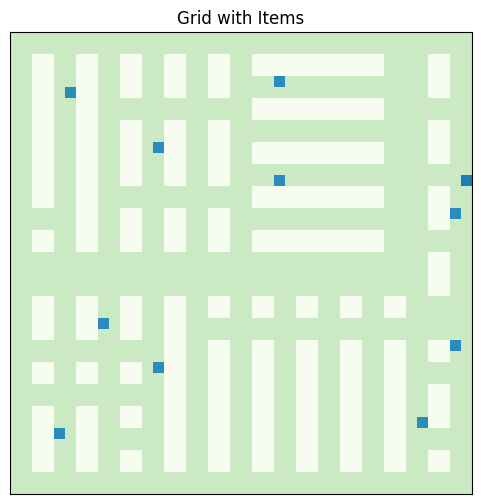

In [142]:
# The agents start position
start = (41, 13)

# Each item location on the grid
items = [
    #(9, 2),
    (13, 10),
    #(37, 9),
    (40, 16),
    #(30, 20),
    (4, 36),
    #(8, 35),
    (13, 30),
    #(20, 31),
    (37, 35),
    #(20, 24),
    (24, 4),
    #(33, 1),
    (5, 5),
    #(20, 18),
    (8, 26),
    #(32, 37),
    (40, 28),
    #(16, 27),
    (24, 13)
]


# Function to visualise the grid with shelfs, items, and start position
def visualizeItems_matplotlib(grid, start, items):
    height = len(grid)
    width = len(grid[0])
    
    # numeric grid
    heat = np.full((height, width), EMPTY, dtype=float)
    
    # shelves
    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                heat[y][x] = WALL   # walls
    
    # items
    for (x, y) in items:
        if EMPTY <= x < width and EMPTY <= y < height:
            heat[y][x] = ITEM
    
    # start
    sx, sy = start
    if EMPTY <= sx < width and EMPTY <= sy < height:
        heat[sy][sx] = START
    
    # plot
    plt.figure(figsize=(6,6))
    plt.imshow(heat, cmap=CMAP, vmin=-1, vmax=3)
    plt.title("Grid with Items")
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Running the function
visualizeItems_matplotlib(grid, start, items)

A* Pathfinding

In [143]:
# ????
def get_neighbors(pos):
    x, y = pos
    
    candidates = [
        (x+1, y),
        (x-1, y),
        (x, y+1),
        (x, y-1)
    ]
    
    valid = []
    for nx, ny in candidates:
        if 0 <= nx < grid_width and 0 <= ny < grid_height:
            valid.append((nx, ny))
    
    return valid

# ????
def heuristic(a, b):
    ax, ay = a
    bx, by = b
    return abs(ax - bx) + abs(ay - by)

In [144]:
# New A*


def astar(grid, start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start))
    
    came_from = {}
    g_score = {start: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal:
            # reconstruct path
            path = []
            temp = current
            
            while temp in came_from:
                path.append(temp)
                temp = came_from[temp]
            
            path.append(start)
            path.reverse()
            
            distance = g_score[current]
            
            return path, distance
        
        for neighbor in get_neighbors(current):
            x, y = neighbor
            
            # bounds
            if not (0 <= x < len(grid[0]) and 0 <= y < len(grid)):
                continue
            
            # wall
            if grid[y][x] == 1:
                continue
            
            tentative = g_score[current] + 1
            
            if neighbor not in g_score or tentative < g_score[neighbor]:
                g_score[neighbor] = tentative
                came_from[neighbor] = current
                
                f = tentative + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor))
    
    return [], float("inf")

In [145]:
points = [start] + items
distance_matrix = {}

for i in range(len(points)):
    for j in range(len(points)):
        if i != j:
            
            path, distance = astar(
                grid,
                points[i],
                points[j]
            )
            
            distance_matrix[(i, j)] = distance

Genetic Algorithm

Godt link til Genetic Algorithms
https://www.tutorialspoint.com/genetic_algorithms/genetic_algorithms_crossover.htm

In [146]:
#import random
NUM_ITEMS = len(items)

In [147]:
def create_population(size):
    population = []
    base = list(range(NUM_ITEMS))
    
    for _ in range(size):
        individual = base[:]
        random.shuffle(individual)
        population.append(individual)
    
    return population

In [148]:
def route_distance(route):
    total = 0
    
    # start → first item
    total += distance_matrix[(0, route[0]+1)]
    
    # between items
    for i in range(len(route)-1):
        total += distance_matrix[(route[i]+1, route[i+1]+1)]
    
    # last item → back to start
    total += distance_matrix[(route[-1]+1, 0)]
    
    return total

In [149]:
# Parent Selection Types: Random, Tournament, Roulette, Rank, SUS

def random_sel(pop): return random.choice(pop)

def tournament_sel(pop):
    return min(random.sample(pop,3), key=route_distance)

def roulette_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    return random.choices(pop,weights=w)[0]

def rank_sel(pop):
    s=sorted(pop,key=route_distance)
    w=list(range(1,len(pop)+1))
    return random.choices(s,weights=w)[0]

def sus_sel(pop):
    w=[1/(route_distance(p)+1) for p in pop]
    total=sum(w)
    pick=random.uniform(0,total)
    cur=0
    for i,p in enumerate(pop):
        cur+=w[i]
        if cur>pick: return p


#Choosing which selection type we want to use
SELECTION="tournament"

def select(pop):
    if SELECTION=="random": return random_sel(pop)
    if SELECTION=="roulette": return roulette_sel(pop)
    if SELECTION=="sus": return sus_sel(pop)
    if SELECTION=="rank": return rank_sel(pop)
    return tournament_sel(pop)

In [150]:
def crossover(p1, p2):
    start, end = sorted(random.sample(range(NUM_ITEMS), 2))
    child = [None]*NUM_ITEMS
    
    child[start:end] = p1[start:end]
    
    fill = [x for x in p2 if x not in child]
    
    idx = 0
    for i in range(NUM_ITEMS):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    
    return child

In [151]:
def mutate(route, rate=0.02):
    if random.random() < rate:
        i, j = random.sample(range(NUM_ITEMS), 2)
        route[i], route[j] = route[j], route[i]
    return route

In [152]:
def genetic_algorithm_with_history(generations=100, size=100):

    pop = create_population(size)

    history = []
    distance_history = []

    best = min(pop, key=route_distance)

    for g in range(generations):

        new_pop = []

        for _ in range(size):

            p1 = select(pop)
            p2 = select(pop)

            child = crossover(p1, p2)
            child = mutate(child)

            new_pop.append(child)

        pop = new_pop

        current = min(pop, key=route_distance)

        if route_distance(current) < route_distance(best):
            best = current

        history.append(best.copy())
        distance_history.append(route_distance(best))

        if g % 10 == 0:
            print(f"Gen {g}: {route_distance(best)}")

    return best, history, distance_history

In [153]:
best, history, distance_history = genetic_algorithm_with_history(
    generations=100,
    size=100
)

best_route = history[-1]

print("Best route:", best_route)
print("Distance:", route_distance(best_route))

Gen 0: 256
Gen 10: 190
Gen 20: 190
Gen 30: 190
Gen 40: 190
Gen 50: 190
Gen 60: 190
Gen 70: 190
Gen 80: 190
Gen 90: 190
Best route: [9, 5, 6, 0, 3, 7, 2, 4, 8, 1]
Distance: 190


In [154]:
# NEW

def build_full_path(route):

    full_path = []

    current = start

    for idx in route:

        target = items[idx]

        # unified A*
        path_segment, _ = astar(
            grid,
            current,
            target
        )

        # unreachable
        if not path_segment:
            print(f"No path from {current} to {target}")
            return []

        # avoid duplicates
        if full_path:
            path_segment = path_segment[1:]

        full_path.extend(path_segment)

        current = target

    # return to start
    path_back, _ = astar(
        grid,
        current,
        start
    )

    if path_back:
        full_path.extend(path_back[1:])

    return full_path

full_path = build_full_path(best_route)

In [155]:
# OLD

def build_full_path(route):
    full_path = []
    
    current = start
    
    for idx in route:
        target = items[idx]
        
        # unified A*
        path_segment, _ = astar(grid, current, target)
        
        if full_path:
            path_segment = path_segment[1:]
        
        full_path.extend(path_segment)
        current = target
    
    # return to start
    path_back, _ = astar(grid, current, start)
    full_path.extend(path_back[1:])
    
    return full_path

full_path = build_full_path(best_route)

print("Best route:", best_route)
print("Distance:", route_distance(best_route))

Best route: [9, 5, 6, 0, 3, 7, 2, 4, 8, 1]
Distance: 190


In [156]:
%matplotlib inline

C:\Users\clama\AppData\Local\Temp\ipykernel_44056\1338018651.py:79: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


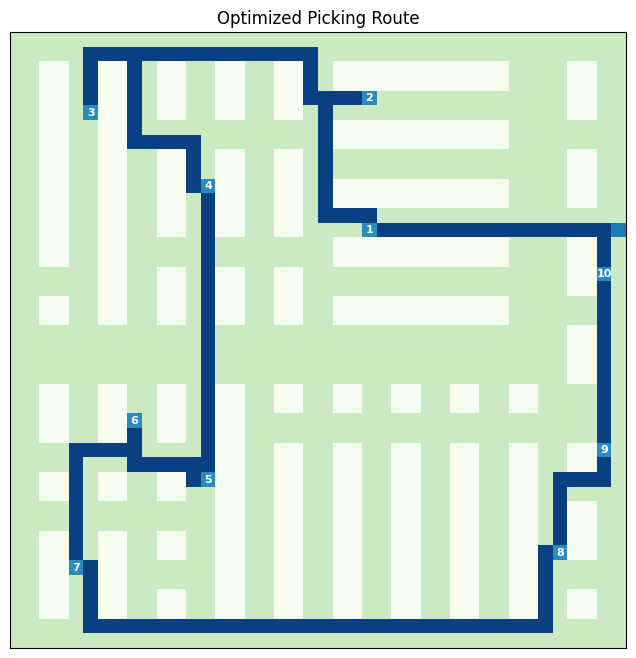

In [157]:
# NEW

def visualizeItems_matplotlib(
    grid,
    full_path,
    start,
    items,
    route
):
    plt.close('all')

    height = len(grid)
    width = len(grid[0])

    heat = np.full(
        (height, width),
        EMPTY,
        dtype=float
    )

    # shelves
    for y in range(height):
        for x in range(width):

            if grid[y][x] == 1:
                heat[y][x] = WALL

    # items
    for (x, y) in items:

        if 0 <= x < width and 0 <= y < height:
            heat[y][x] = ITEM

    # start
    sx, sy = start

    if 0 <= sx < width and 0 <= sy < height:
        heat[sy][sx] = START

    # path
    for (x, y) in full_path:

        if 0 <= x < width and 0 <= y < height:

            if (x, y) != start and (x, y) not in items:
                heat[y][x] = AGENT

    # ---------- PLOT ----------
    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3
    )

    # order numbers
    for order, item_idx in enumerate(route):

        x, y = items[item_idx]

        ax.text(
            x,
            y,
            str(order + 1),
            color="white",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

    ax.set_title("Optimized Picking Route")

    ax.set_xticks([])
    ax.set_yticks([])

    fig.show()

# Running the function
visualizeItems_matplotlib(grid, full_path, start, items, best_route)

In [158]:
# NEW

def animate_heatmap_funcanimation(
    grid,
    path,
    start,
    items,
    trail_length=10,
    interval=50
):

    height = len(grid)
    width = len(grid[0])

    item_set = set(items)

    # ---------- STATIC BASE ----------
    base_heat = np.full((height, width), EMPTY, dtype=float)

    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                base_heat[y][x] = WALL

    # ---------- FIGURE ----------
    fig, ax = plt.subplots(figsize=(6,6))

    heat = base_heat.copy()

    img = ax.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3,
        animated=True
    )

    ax.set_xticks([])
    ax.set_yticks([])

    # ---------- UPDATE FUNCTION ----------
    def update(frame):

        current = path[frame]

        # reset frame
        heat = base_heat.copy()

        # ---------- TRAIL ----------
        start_idx = max(0, frame - trail_length)

        trail = path[start_idx:frame+1]

        for i, (x, y) in enumerate(trail):

            intensity = (i + 1) / len(trail)

            heat[y][x] = 0.2 + intensity * 1.8

        # ---------- VISITED ITEMS ----------
        visited_items = set(path[:frame+1]) & item_set

        for (x, y) in items:

            if (x, y) in visited_items:
                heat[y][x] = ITEM_PICKED
            else:
                heat[y][x] = ITEM

        # ---------- AGENT ----------
        x, y = current
        heat[y][x] = AGENT

        # ---------- START ----------
        sx, sy = start
        heat[sy][sx] = START

        # ---------- UPDATE IMAGE ----------
        img.set_array(heat)

        ax.set_title(
            f"Step {frame+1}/{len(path)} | "
            f"Collected: {len(visited_items)}/{len(items)}"
        )

        return [img]

    # ---------- CREATE ANIMATION ----------
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(path),
        interval=interval,
        blit=False,
        repeat=False
    )

    return ani

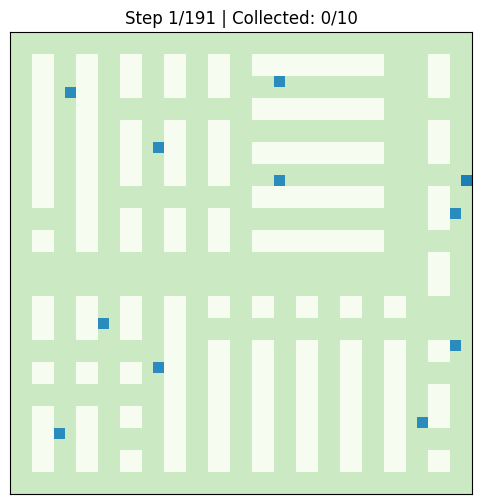

In [159]:
from IPython.display import HTML

ani = animate_heatmap_funcanimation(
    grid,
    full_path,
    start,
    items
)

HTML(ani.to_jshtml())

In [160]:
def animate_ga_evolution(
    grid,
    history,
    distance_history,
    start,
    items,
    interval=150,
    generation_step=5
):

    height = len(grid)
    width = len(grid[0])

    # ---------- GENERATIONS TO SHOW ----------
    shown_generations = list(
        range(0, len(history), generation_step)
    )

    # ---------- STATIC BASE ----------
    base_heat = np.full((height, width), EMPTY, dtype=float)

    for y in range(height):
        for x in range(width):
            if grid[y][x] == 1:
                base_heat[y][x] = WALL

    # ---------- FIGURE ----------
    fig = plt.figure(figsize=(12,6))

    # LEFT = warehouse
    ax_grid = fig.add_subplot(1, 2, 1)

    # RIGHT = convergence graph
    ax_graph = fig.add_subplot(1, 2, 2)

    heat = base_heat.copy()

    img = ax_grid.imshow(
        heat,
        cmap=CMAP,
        vmin=-1,
        vmax=3,
        animated=True
    )

    ax_grid.set_xticks([])
    ax_grid.set_yticks([])

    # ---------- GRAPH SETUP ----------
    ax_graph.set_title("GA Convergence")

    ax_graph.set_xlabel("Generation")
    ax_graph.set_ylabel("Distance")

    ax_graph.set_xlim(0, len(history))

    ax_graph.set_ylim(
        min(distance_history) * 0.95,
        max(distance_history) * 1.05
    )

    line, = ax_graph.plot([], [])

    # ---------- UPDATE FUNCTION ----------
    def update(frame_idx):

        gen = shown_generations[frame_idx]

        route = history[gen]

        heat = base_heat.copy()

        # ---------- BUILD PATH ----------
        full_path = build_full_path(route)

        # ---------- GENERATION COLOR ----------
        generation_progress = gen / len(history)

        # path intensity evolves over generations
        path_value = 0.5 + generation_progress * 2.0

        # ---------- DRAW PATH ----------
        for (x, y) in full_path:

            if (x, y) != start and (x, y) not in items:
                heat[y][x] = path_value

        # ---------- ITEMS ----------
        for item in items:

            x, y = item

            heat[y][x] = ITEM

        # ---------- START ----------
        sx, sy = start
        heat[sy][sx] = START

        # ---------- UPDATE GRID ----------
        img.set_array(heat)

        # ---------- REMOVE OLD TEXT ----------
        for txt in ax_grid.texts:
            txt.remove()

        # ---------- DRAW ORDER NUMBERS ----------
        for order, item_idx in enumerate(route):

            x, y = items[item_idx]

            ax_grid.text(
                x,
                y,
                str(order + 1),
                color="white",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold"
            )

        # ---------- GRID TITLE ----------
        ax_grid.set_title(
            f"Generation {gen+1}/{len(history)}\n"
            f"Distance: {route_distance(route)}"
        )

        # ---------- UPDATE GRAPH ----------
        x_data = list(range(gen + 1))
        y_data = distance_history[:gen + 1]

        line.set_data(x_data, y_data)

        return [img, line]

    # ---------- CREATE ANIMATION ----------
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(shown_generations),
        interval=interval,
        blit=False,
        repeat=False
    )

    return ani

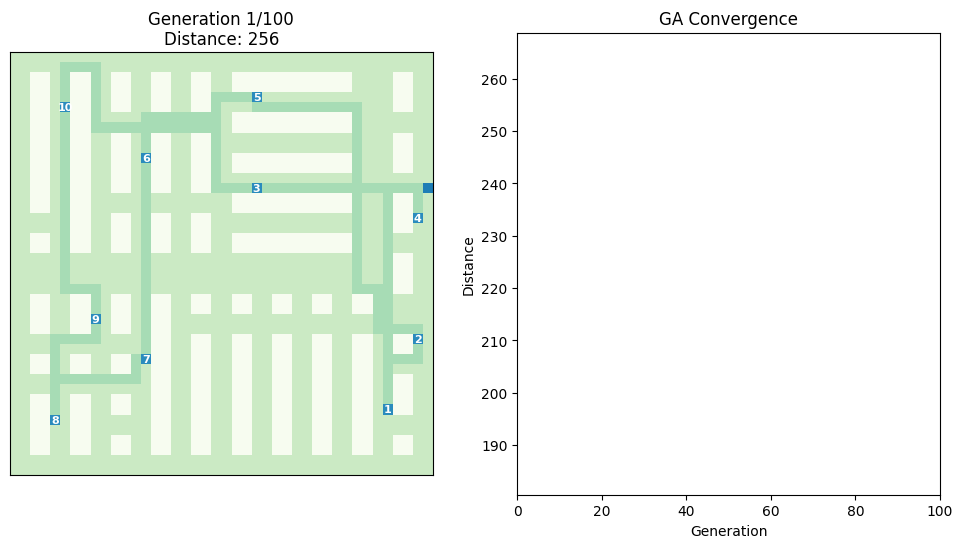

In [161]:
ani = animate_ga_evolution(
    grid,
    history,
    distance_history,
    start,
    items,
    interval=150,
    generation_step=5
)

HTML(ani.to_jshtml())